In [4]:
from IPython.core.interactiveshell import get_default_colors
!pip install geopandas

# Import necessary libraries for spatial analysis
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

Geopandas and other libraries are imported.
Now, you can proceed with loading your road network data.


In [17]:
!pip install osmnx

In [7]:
import osmnx as ox
place_name = "Manchester, UK"
graph = ox.graph_from_place(place_name, network_type="drive")
roads_gdf = ox.graph_to_gdfs(graph, nodes=False)

In [11]:
df=pd.read_csv(r'/content/dft-road-casualty-statistics-vehicle-provisional-2025.csv')

/tmp/ipykernel_3402/2552684540.py:1: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r'/content/dft-road-casualty-statistics-vehicle-provisional-2025.csv')


In [18]:

df.head()

,collision_index,collision_year,collision_ref_no,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre_historic,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,...,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,lsoa_of_driver,escooter_flag,driver_distance_banding
0,2025010551784,2025,10551784,3,9,0,18,19,7,3,...,55,8,-1,-1,-1,-1,4,E01002814,0,2
1,2025010551784,2025,10551784,2,9,0,18,19,3,7,...,36,7,-1,-1,-1,-1,6,E01000892,0,1
2,2025010551784,2025,10551784,1,9,0,18,19,7,3,...,53,8,-1,-1,-1,-1,-1,-1,0,-1
3,2025010551786,2025,10551786,1,3,0,-1,-1,9,9,...,30,6,-1,-1,-1,-1,3,E01004669,0,1
4,2025010551786,2025,10551786,2,9,0,6,6,9,9,...,49,8,-1,-1,-1,-1,5,E01015718,0,4


In [13]:
df.count()

,0
collision_index,87805
collision_year,87805
collision_ref_no,87805
vehicle_reference,87805
vehicle_type,87805
towing_and_articulation,87805
vehicle_manoeuvre_historic,87805
vehicle_manoeuvre,87805
vehicle_direction_from,87805
vehicle_direction_to,87805


In [14]:
df.isnull()

,collision_index,collision_year,collision_ref_no,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre_historic,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,...,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,lsoa_of_driver,escooter_flag,driver_distance_banding
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87800,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
87801,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
87802,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
87803,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [16]:
df.shape

(87805, 32)

In [19]:
junction_locations = df['junction_location'].value_counts().reset_index()
junction_locations.columns = ['junction_location', 'count']
display(junction_locations)

,junction_location,count
0,0,36645
1,1,18226
2,8,12325
3,9,5123
4,2,4613
5,6,3875
6,4,2522
7,5,2164
8,3,1436
9,-1,660


<Axes: >

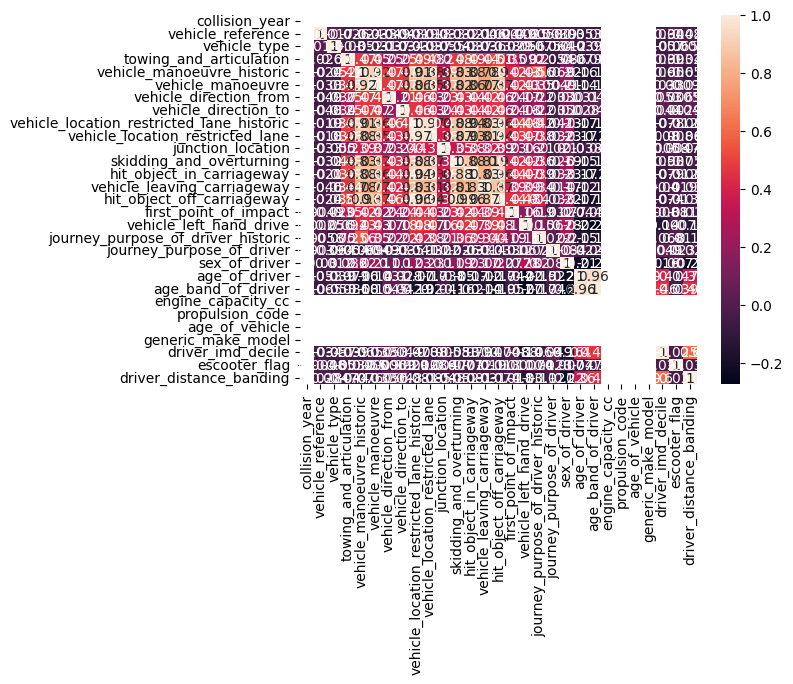

In [33]:
import seaborn as sns
corelation = df.corr(numeric_only=True)
sns.heatmap(corelation, xticklabels=corelation.columns, yticklabels=corelation.columns, annot=True)

In [38]:
# Calculate the count of each age band
age_band_counts = df['age_band_of_driver'].value_counts().reset_index()
age_band_counts.columns = ['age_band_of_driver', 'count']

# Sort by age band for better visualization
age_band_counts = age_band_counts.sort_values(by='age_band_of_driver').reset_index(drop=True)

# Display the results
display(age_band_counts)

,age_band_of_driver,count
0,-1,13166
1,1,357
2,2,190
3,3,1002
4,4,5996
5,5,7708
6,6,16456
7,7,14409
8,8,11550
9,9,9374


/tmp/ipykernel_3402/1473254989.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_band_of_driver', y='count', data=age_band_counts, palette='viridis')


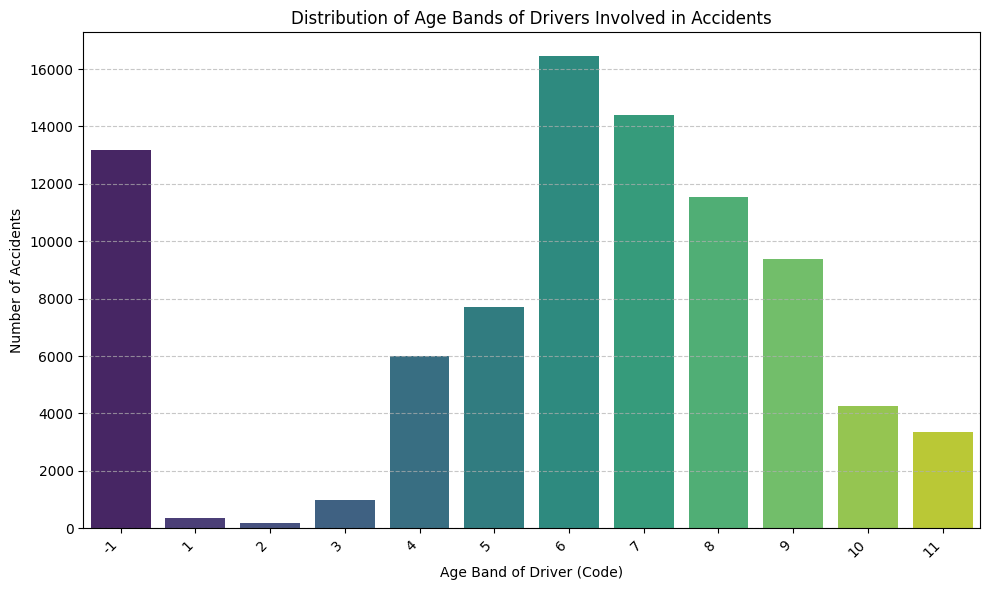

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a mapping for age band codes to actual age ranges if available, or keep codes as labels
# Assuming -1 means 'Data not available' based on common datasets.
# If you have a data dictionary for 'age_band_of_driver', we can refine these labels.
# For now, let's assume age bands are numerical representations.

plt.figure(figsize=(10, 6))
sns.barplot(x='age_band_of_driver', y='count', data=age_band_counts, palette='viridis')
plt.title('Distribution of Age Bands of Drivers Involved in Accidents')
plt.xlabel('Age Band of Driver (Code)')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [45]:
#calculate the count of sex of drivers who involves in accidents
sex_of_driver_counts=df['sex_of_driver'].value_counts().reset_index()
sex_of_driver_counts.columns=['sex_of_driver','count']
sex_of_driver_counts = sex_of_driver_counts.sort_values(by='sex_of_driver').reset_index(drop=True)
display(sex_of_driver_counts)

,sex_of_driver,count
0,-1,1929
1,1,53493
2,2,22476
3,3,9907


/tmp/ipykernel_3402/248739553.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex_of_driver', y='count', data=sex_of_driver_counts, palette='viridis')


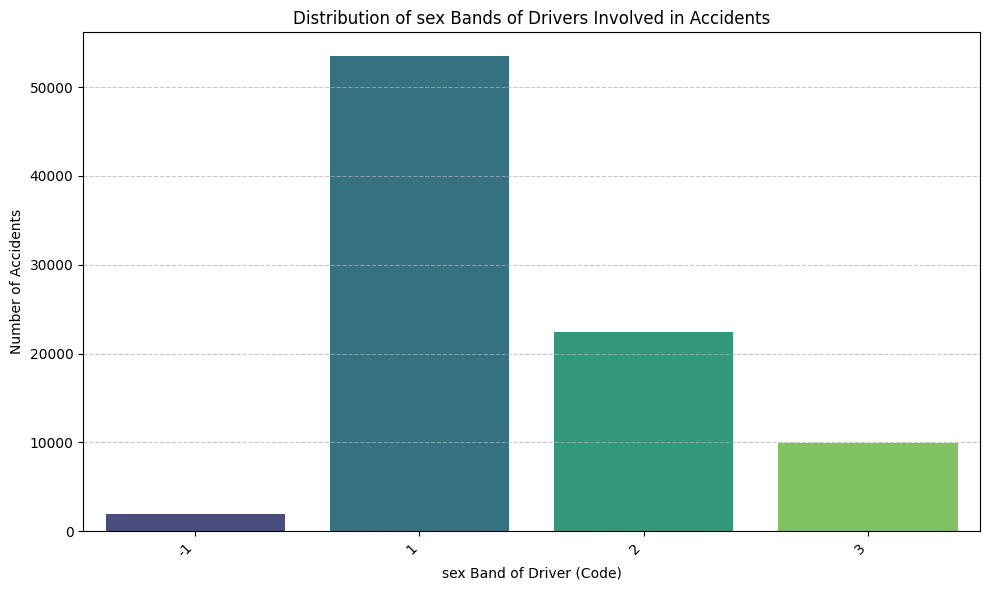

In [49]:
plt.figure(figsize=(10, 6))
sns.barplot(x='sex_of_driver', y='count', data=sex_of_driver_counts, palette='viridis')
plt.title('Distribution of sex Bands of Drivers Involved in Accidents')
plt.xlabel('sex Band of Driver (Code)')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Total Unique Accidents in 2025

In [50]:
# Calculate the total number of unique collisions
total_unique_accidents = df['collision_index'].nunique()
print(f"Total unique accidents recorded in 2025: {total_unique_accidents}")

Total unique accidents recorded in 2025: 48474


### Data Cleaning and 'Average' Age and Sex Calculation

For `age_of_driver`, `age_band_of_driver`, and `sex_of_driver`, values like -1 or 3 often represent 'unknown' or 'not specified'. To calculate meaningful averages and modes, we will filter these out. We will consider valid codes for `sex_of_driver` to be 1 (Male) and 2 (Female), and for `age_of_driver` and `age_band_of_driver` to be values greater than or equal to 0.

In [53]:
# Filter out 'unknown' or 'not applicable' values for age and sex
cleaned_df = df[(df['age_of_driver'] >= 0) & (df['age_band_of_driver'] >= 0) & (df['sex_of_driver'].isin([1, 2]))].copy()

# Check if cleaned_df is empty after filtering
if cleaned_df.empty:
    print("No valid driver data found after cleaning for age and sex.")
else:
    # Calculate the most frequent age band
    most_frequent_age_band = cleaned_df['age_band_of_driver'].mode()[0]
    print(f"Most frequent age band of drivers in accidents (excluding unknown): {most_frequent_age_band}")

    # Calculate the average age of drivers
    average_age_of_driver = cleaned_df['age_of_driver'].mean()
    print(f"Average age of drivers in accidents (excluding unknown): {average_age_of_driver:.2f} years")

    # Calculate the most frequent sex of drivers
    most_frequent_sex = cleaned_df['sex_of_driver'].mode()[0]
    sex_mapping = {1: 'Male', 2: 'Female'}
    print(f"Most frequent sex of drivers in accidents (excluding unknown): {sex_mapping.get(most_frequent_sex, 'Unknown')}")

    # Re-display the visualizations for age band and sex with cleaned data context, if needed.
    # However, the previous plots already show the distribution including -1/3, which is also informative.
    print("\nVisualizations for age band and sex distribution have already been generated earlier in the chat.")

Most frequent age band of drivers in accidents (excluding unknown): 6
Average age of drivers in accidents (excluding unknown): 41.80 years
Most frequent sex of drivers in accidents (excluding unknown): Male

Visualizations for age band and sex distribution have already been generated earlier in the chat.


In [58]:
most_frequent_collisions_occured_year=cleaned_df['collision_year'].mode()[0]
print(f"most accidents occured in the year is (excluding unkown): {most_frequent_collisions_occured_year}")

most accidents occured in the year is (excluding unkown): 2025


In [59]:
most_frequent_vehicle_type=cleaned_df['vehicle_type'].mode()[0]
print(f"most collisions ivolved by the vehicle is (exclude unknown): {most_frequent_vehicle_type}")

most collisions ivolved by the vehicle is (exclude unknown): 9
